# INF8239_U01 — Clasificación con SVM

## Práctica Guiada — LAB02

**Estudiante:** Laudys Jerusi Zapata  
**Programa:** Maestría en Ciencia de Datos e Inteligencia Artificial  
**Universidad:** Universidad Autónoma de Santo Domingo (UASD)  
**Asignatura:** Ciencia de Datos e Inteligencia Artificial  
**Práctica:** LAB02 — Clasificación con SVM  

### Pregunta de análisis

¿Es posible clasificar los centros educativos de la República Dominicana según su nivel de promoción académica en las Pruebas Nacionales del período **2024**, utilizando información disponible sobre sus resultados en las áreas evaluadas y características del centro?

### Unidad de análisis

Centro educativo.

### Período de análisis

**2024**

### Variable objetivo

Nivel de promoción académica del centro educativo, construido a partir de la tasa de promoción.

### Tipo de problema

Clasificación binaria supervisada.

### Modelo principal

Support Vector Machine (SVM) con kernel RBF.

### Prevención de fuga de información

Las variables utilizadas directamente para construir la variable objetivo, así como variables derivadas del resultado final, no serán utilizadas como predictores.

In [3]:
# 1. Cargar y reconocer el esquema

import pandas as pd

df = pd.read_csv(
    "../data/raw/pruebas_nacionales_2016_2024.csv",
    sep=";",
    encoding="latin1"
)

print(df.shape)
print(df.dtypes)
print(df.head())
print(df.tail())

assert not df.empty

(57586, 16)
Período                      int64
Convocatoria               float64
Regional                     int64
Distrito                     int64
Nivel/Modalidad                str
Código de Centro             int64
Nombre de Centro               str
Español                    float64
Matemáticas                float64
Sociales                   float64
Naturales                  float64
Cantidad de estudiantes      int64
Cantidad Femenino            int64
Cantidad masculino           int64
Cantidad Promovidos          int64
Cantidad Aplazados         float64
dtype: object
   Período  Convocatoria  Regional  Distrito        Nivel/Modalidad  \
0     2016           1.0         1       101  BASICA ADULTOS FORMAL   
1     2016           1.0         1       101  BASICA ADULTOS FORMAL   
2     2016           1.0         1       102  BASICA ADULTOS FORMAL   
3     2016           1.0         1       102  BASICA ADULTOS FORMAL   
4     2016           1.0         1       103  BASICA ADULTO

In [4]:
# 2. Construir la auditoría

audit = pd.DataFrame({
    "tipo": df.dtypes.astype(str),
    "ausentes": df.isna().sum(),
    "porcentaje_ausente": (df.isna().mean()*100).round(2),
    "unicos": df.nunique(dropna=False)
}).sort_values("porcentaje_ausente", ascending=False)

print("Duplicados:", df.duplicated().sum())

display(audit)

Duplicados: 2767


,tipo,ausentes,porcentaje_ausente,unicos
Matemáticas,float64,5337,9.27,8700
Español,float64,5233,9.09,8824
Naturales,float64,5231,9.08,8626
Sociales,float64,5182,9.00,8620
Cantidad Aplazados,float64,4935,8.57,206
Convocatoria,float64,4935,8.57,4
Regional,int64,0,0.00,18
Período,int64,0,0.00,8
Nombre de Centro,str,0,0.00,5908
Código de Centro,int64,0,0.00,6622


In [5]:
# 3. Definir target y retirar fugas
# Seleccionar únicamente el período 2024

df_2024 = df[df["Período"] == 2024].copy()

print("Dimensiones del dataset 2024:", df_2024.shape)
print("\nPeríodos incluidos:")
print(df_2024["Período"].value_counts())

assert not df_2024.empty
assert df_2024["Período"].nunique() == 1
assert df_2024["Período"].iloc[0] == 2024

Dimensiones del dataset 2024: (3474, 16)

Períodos incluidos:
Período
2024    3474
Name: count, dtype: int64


In [6]:
# 4. Definir target y retirar fugas
# Construcción de la tasa de promoción y del target

df_2024["tasa_promocion"] = (
    df_2024["Cantidad Promovidos"] /
    df_2024["Cantidad de estudiantes"]
)

punto_corte = df_2024["tasa_promocion"].median()

df_2024["target_promocion"] = (
    df_2024["tasa_promocion"] >= punto_corte
).astype(int)

print("Punto de corte:", round(punto_corte, 4))
print("\nDistribución del target:")
print(df_2024["target_promocion"].value_counts().sort_index())

assert df_2024["target_promocion"].notna().all()
assert df_2024["target_promocion"].nunique() == 2

Punto de corte: 0.8037

Distribución del target:
target_promocion
0    1737
1    1737
Name: count, dtype: int64


In [7]:
# 5. Definir target y retirar fugas
# Retirar variables que contienen información del resultado
# o identificadores que no deben utilizarse como predictores.

TARGET = "target_promocion"

DROP_COLUMNS = [
    "Período",
    "Convocatoria",
    "Código de Centro",
    "Nombre de Centro",
    "Cantidad de estudiantes",
    "Cantidad Promovidos",
    "Cantidad Aplazados",
    "Cantidad Femenino",
    "Cantidad masculino",
    "tasa_promocion"
]

assert TARGET in df_2024.columns

X = df_2024.drop(columns=[TARGET] + DROP_COLUMNS)
y = df_2024[TARGET]

print("Variables predictoras:")
print(X.columns.tolist())

print("\nDimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

print("\nDistribución del target:")
print(y.value_counts().sort_index())

assert y.notna().all()
assert y.nunique() >= 2

Variables predictoras:
['Regional', 'Distrito', 'Nivel/Modalidad', 'Español', 'Matemáticas', 'Sociales', 'Naturales']

Dimensiones de X: (3474, 7)
Dimensiones de y: (3474,)

Distribución del target:
target_promocion
0    1737
1    1737
Name: count, dtype: int64


In [8]:
# 6. Separar tipos y crear preprocesamiento

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

num_cols = X.select_dtypes(include="number").columns.tolist()
cat_cols = X.select_dtypes(exclude="number").columns.tolist()

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols)
])

print("Variables numéricas:", num_cols)
print("Cantidad de variables numéricas:", len(num_cols))

print("\nVariables categóricas:", cat_cols)
print("Cantidad de variables categóricas:", len(cat_cols))

Variables numéricas: ['Regional', 'Distrito', 'Español', 'Matemáticas', 'Sociales', 'Naturales']
Cantidad de variables numéricas: 6

Variables categóricas: ['Nivel/Modalidad']
Cantidad de variables categóricas: 1


In [9]:
# 7. Dividir, baseline y SVM
# División de entrenamiento y prueba

from sklearn.model_selection import train_test_split

Xtr, Xte, ytr, yte = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", Xtr.shape)
print("Prueba:", Xte.shape)

print("\nDistribución del target en entrenamiento:")
print(ytr.value_counts(normalize=True).sort_index().round(3))

print("\nDistribución del target en prueba:")
print(yte.value_counts(normalize=True).sort_index().round(3))

Entrenamiento: (2779, 7)
Prueba: (695, 7)

Distribución del target en entrenamiento:
target_promocion
0    0.5
1    0.5
Name: proportion, dtype: float64

Distribución del target en prueba:
target_promocion
0    0.501
1    0.499
Name: proportion, dtype: float64


In [10]:
# 8. Dividir, baseline y SVM
# Modelo baseline: DummyClassifier

from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

dummy = Pipeline([
    ("prep", preprocess),
    ("model", DummyClassifier(strategy="most_frequent"))
])

dummy.fit(Xtr, ytr)

pred_dummy = dummy.predict(Xte)

f1_dummy = f1_score(
    yte,
    pred_dummy,
    average="macro"
)

print("Baseline — DummyClassifier")
print("F1 macro:", round(f1_dummy, 4))

Baseline — DummyClassifier
F1 macro: 0.333


In [12]:
# 9. Dividir, baseline y SVM
# Evaluación del modelo SVM

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy_svm = accuracy_score(yte, pred_svm)
precision_svm = precision_score(yte, pred_svm, zero_division=0)
recall_svm = recall_score(yte, pred_svm, zero_division=0)
f1_svm = f1_score(yte, pred_svm, average="macro")

print("MÉTRICAS DEL MODELO SVM")
print("------------------------")
print("Accuracy: ", round(accuracy_svm, 4))
print("Precision:", round(precision_svm, 4))
print("Recall:   ", round(recall_svm, 4))
print("F1 macro: ", round(f1_svm, 4))

MÉTRICAS DEL MODELO SVM
------------------------
Accuracy:  0.6935
Precision: 0.7219
Recall:    0.6282
F1 macro:  0.6922


In [13]:
# 10. Dividir, baseline y SVM
# Reporte de clasificación del modelo SVM

from sklearn.metrics import classification_report

print("REPORTE DE CLASIFICACIÓN — SVM")
print("--------------------------------")

print(
    classification_report(
        yte,
        pred_svm,
        target_names=["Bajo nivel de promoción", "Alto nivel de promoción"],
        zero_division=0
    )
)

REPORTE DE CLASIFICACIÓN — SVM
--------------------------------
                         precision    recall  f1-score   support

Bajo nivel de promoción       0.67      0.76      0.71       348
Alto nivel de promoción       0.72      0.63      0.67       347

               accuracy                           0.69       695
              macro avg       0.70      0.69      0.69       695
           weighted avg       0.70      0.69      0.69       695



In [14]:
# 10. Dividir, baseline y SVM
# Cálculo de ROC-AUC

from sklearn.metrics import roc_auc_score

prob_svm = svm.predict_proba(Xte)[:, 1]

roc_auc_svm = roc_auc_score(
    yte,
    prob_svm
)

print("ROC-AUC del modelo SVM:", round(roc_auc_svm, 4))

ROC-AUC del modelo SVM: 0.752


Matriz de confusión:
[[264  84]
 [129 218]]


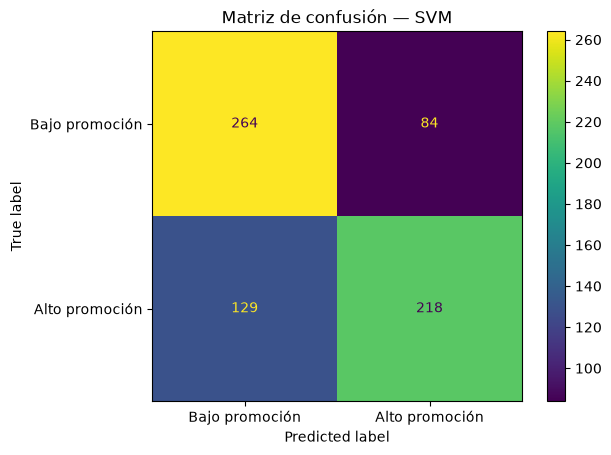

In [15]:
# 11. Dividir, baseline y SVM
# Matriz de confusión del modelo SVM

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(yte, pred_svm)

print("Matriz de confusión:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Bajo promoción", "Alto promoción"]
)

disp.plot()
plt.title("Matriz de confusión — SVM")
plt.show()

In [16]:
# 12. Dividir, baseline y SVM
# Comparación entre el baseline y el modelo SVM

comparacion = pd.DataFrame({
    "Modelo": ["DummyClassifier", "SVM RBF"],
    "F1 macro": [f1_dummy, f1_svm]
})

display(comparacion)

,Modelo,F1 macro
0,DummyClassifier,0.333013
1,SVM RBF,0.692177


In [17]:
# 13. Dividir, baseline y SVM
# Identificación de errores de clasificación

errores = Xte.copy()

errores["real"] = yte.values
errores["predicho"] = pred_svm

errores = errores[
    errores["real"] != errores["predicho"]
].copy()

print("Cantidad de errores:", len(errores))
print("\nDistribución de los errores:")
print(
    errores[["real", "predicho"]]
    .value_counts()
    .sort_index()
)

display(errores.head(10))

Cantidad de errores: 213

Distribución de los errores:
real  predicho
0     1            84
1     0           129
Name: count, dtype: int64


,Regional,Distrito,Nivel/Modalidad,Español,Matemáticas,Sociales,Naturales,real,predicho
57164,15,1505,ACADÉMICA,59.894737,59.105263,61.388889,59.100000,0,1
57135,15,1505,ACADÉMICA,55.916667,58.166667,60.541667,56.958333,1,0
54995,6,604,ADULTOS FORMAL,56.652174,61.739130,58.347826,56.739130,1,0
55135,6,607,ADULTOS FORMAL,47.000000,47.000000,33.000000,33.000000,1,0
56615,14,1402,TÉCNICO PROFESIONAL,59.100000,59.739130,58.700000,60.000000,0,1
57235,15,1505,MODALIDAD GENERAL,63.000000,NaN,73.000000,63.000000,0,1
54443,3,304,ACADÉMICA,57.476190,56.904762,58.000000,58.666667,1,0
56934,15,1503,ACADÉMICA,58.400000,58.100000,59.600000,65.900000,0,1
57574,18,1805,ADULTOS FORMAL,75.666667,49.000000,49.000000,83.333333,1,0
57297,16,1601,MODALIDAD GENERAL,62.400000,61.666667,66.857143,63.666667,0,1


In [18]:
# 14. Dividir, baseline y SVM
# Resumen consolidado de resultados

resultados = pd.DataFrame({
    "Modelo": ["DummyClassifier", "SVM RBF"],
    "Accuracy": [
        accuracy_score(yte, pred_dummy),
        accuracy_svm
    ],
    "Precision": [
        precision_score(yte, pred_dummy, zero_division=0),
        precision_svm
    ],
    "Recall": [
        recall_score(yte, pred_dummy, zero_division=0),
        recall_svm
    ],
    "F1 macro": [
        f1_dummy,
        f1_svm
    ]
})

resultados = resultados.round(4)

display(resultados)

,Modelo,Accuracy,Precision,Recall,F1 macro
0,DummyClassifier,0.4993,0.4993,1.0000,0.3330
1,SVM RBF,0.6935,0.7219,0.6282,0.6922
